# Salary Analysis

This section evaluates salary distributions and the relationship between compensation and job demand. It covers the distribution of salaries for top data roles, a comparison of the highest-paid skills versus the most in-demand skills, and a country-specific salary breakdown, offering insights into where data professionals can earn the most.

## Salary Distribution for the Top Data Roles

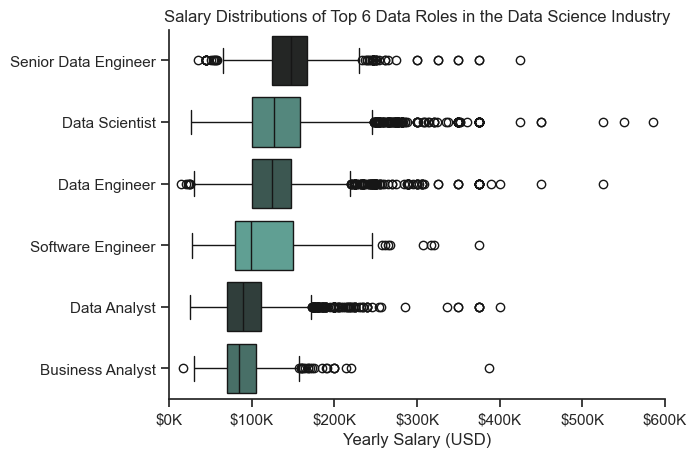

In [17]:
# Prepare Data: Creates list of job roles and filters dataframe
job_titles = df['job_title_short'].value_counts().index[:6].tolist()
df_filtered = df[df['job_title_short'].isin(job_titles)]

# Build Data: Groups and sorts data, taking median of each job role
job_order = df_filtered.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

# Plot and Visualize
sns.set_theme(style='ticks')
sns.boxplot(data=df_filtered, x='salary_year_avg', y='job_title_short', order=job_order, palette='dark:#5A9', hue='job_title_short')
sns.despine()

plt.title('Salary Distributions of Top 6 Data Roles in the Data Science Industry')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.show()

Senior Data Engineers command the highest median salaries, with a tight range indicating consistently high compensation. Data Scientists and Data Engineers follow, both centered around $100K, but with numerous outliers reaching $200K–$500K, highlighting strong demand for advanced technical skills.

Software Engineers display a broad salary range, with its upper IQR overlapping with Senior Data Engineers’ median, while its lower IQR extends just below Data/Business Analysts’ median. Outliers for higher compensation are minimal.
Data Analysts and Business Analysts cluster around $80K, though Data Analysts have occasional outliers that exceed $200K, which is not present for Business Analysts. This trend underscores how specialization and advanced technical skills significantly enhance earning potential in the data industry.

A good trajectory for Data Analysts and Business Analysts is to move towards Data Scientist roles. While Software Engineers to Senior Data Engineers.

## Highest Paid Skills for Top Roles (vs. Most In-Demand Skills)

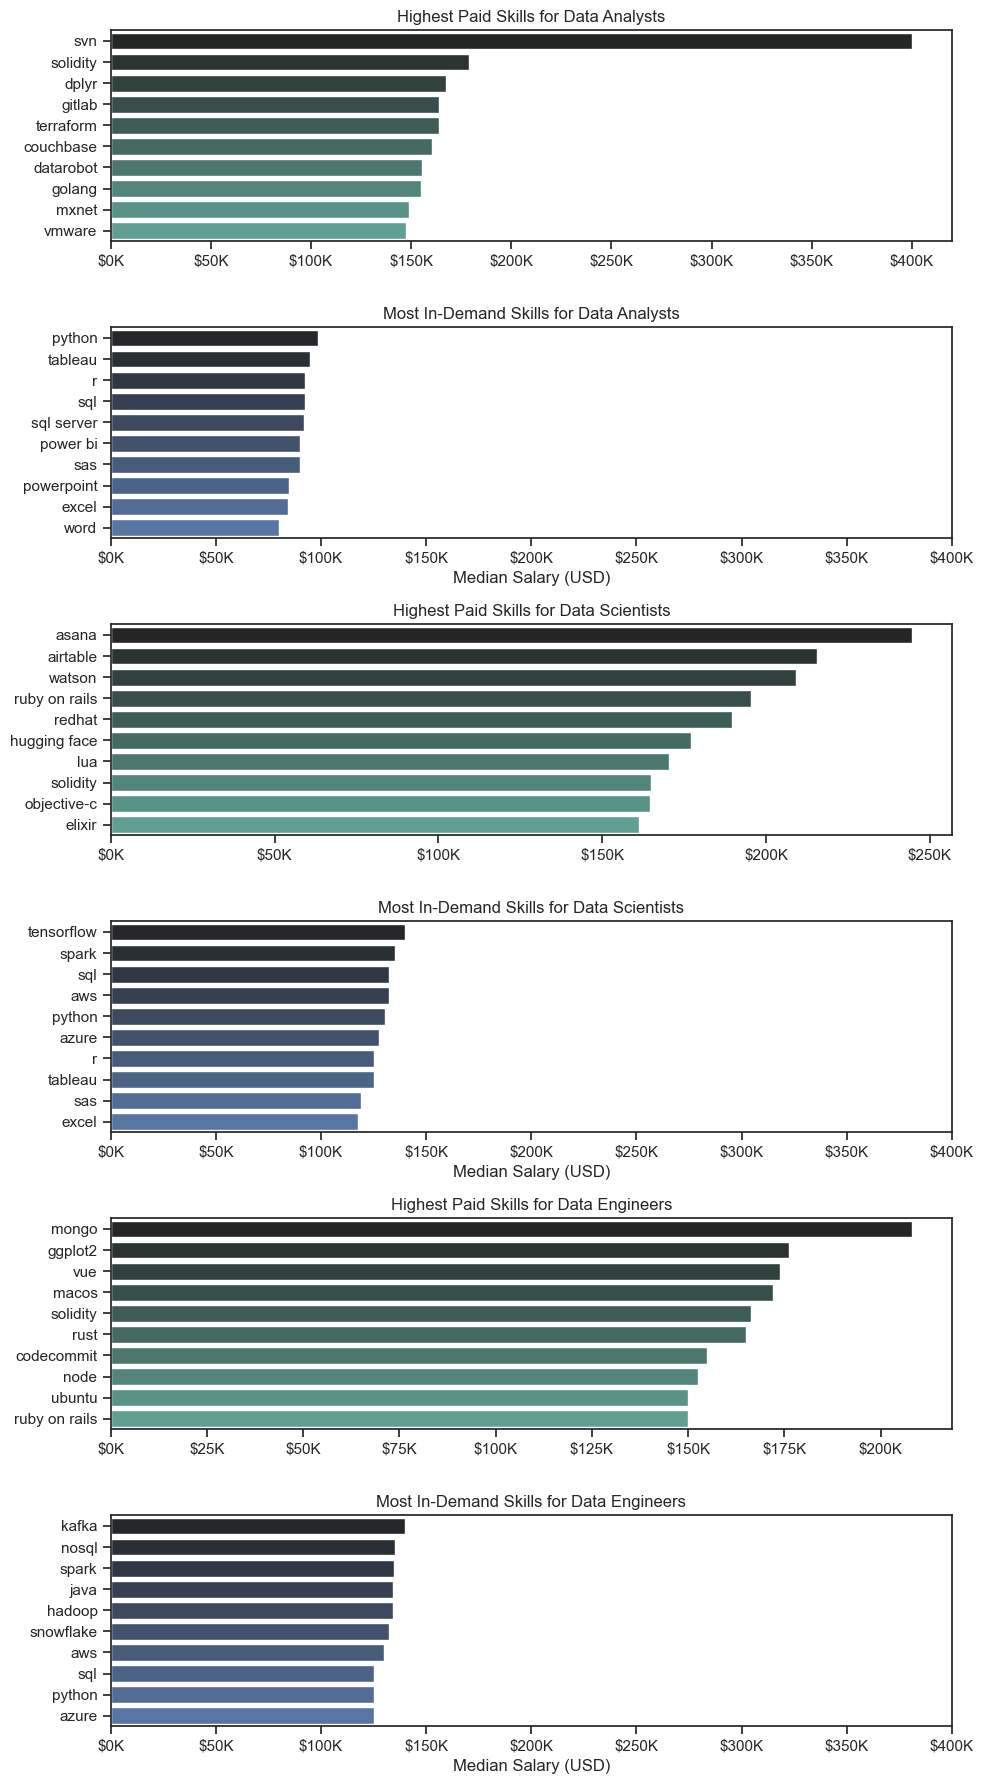

In [16]:
# Prepare Data: Defines job titles to iterate through and prepares subplots
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']
fig, axes = plt.subplots(len(job_titles) * 2, 1, figsize=(10, len(job_titles) * 6))

# Create For Loop: Loops through each job title and createa a barplot
for i, job_title in enumerate(job_titles):

    # Prepare Data: Selects current job title being used, drops its corresponding salaries, and unpacks its job skills.
    df_filtered = df[df['job_title_short'] == job_title]
    df_dropped = df_filtered.dropna(subset=['salary_year_avg'])
    df_exploded = df_dropped.explode('job_skills')

    # Build Data: Groups the (a) highest paying skills and (b) most in-demand skills
    df_top_pay = df_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False).head(10)
    df_top_count = df_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

    # Plot 1: Highest Paid Skills
    sns.barplot(data=df_top_pay, x='median', y='job_skills', ax=axes[i * 2], palette='dark:#5A9', hue='job_skills')

    axes[i * 2].set_title(f'Highest Paid Skills for {job_title}s')
    axes[i * 2].set_xlabel('')
    axes[i * 2].set_ylabel('')
    axes[i * 2 + 1].set_xlim(0,400000)
    axes[i * 2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

    # Plot 2: Most In-Demand Skills
    sns.barplot(data=df_top_count, x='median', y='job_skills', ax=axes[i * 2 + 1], palette='dark:b', hue='job_skills')

    axes[i * 2 + 1].set_title(f'Most In-Demand Skills for {job_title}s')
    axes[i * 2 + 1].set_xlabel('Median Salary (USD)')
    axes[i * 2 + 1].set_ylabel('')
    axes[i * 2 + 1].set_xlim(0,400000)
    axes[i * 2 + 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# Plot and Visualize: Finishing
sns.set_theme(style='ticks')
plt.tight_layout()
plt.show()

Common industry staples like Python, SQL, AWS, and Spark dominate demand, indicating their necessity for most data-related jobs. However, the highest-paid skills lean towards specialized and emerging technologies.

For Data Analysts, high-paying skills like SVN, Terraform, and Couchbase suggest that expertise in DevOps, automation, and database management is highly valued. For Data Scientists, lucrative skills such as Watson, Hugging Face, and Red Hat indicate a demand for AI, deep learning, and enterprise software. Data Engineers' top-paying skills include MongoDB, ggplot2, and Vue.js, showing that proficiency in big data, visualization, and backend development can significantly boost salaries. While foundational tools are essential, niche expertise commands premium compensation.

For professionals starting with high-demand skills like Python, SQL, and AWS, a logical career trajectory involves specialization in cloud computing, automation, AI/ML, or database systems to achieve higher salaries.

Data Analysts can move toward data engineering or cloud analytics by learning Couchbase, Golang, or Terraform. Data Scientists aiming for greater earning potential should focus on AI frameworks, automation (Watson, Hugging Face), and cloud computing. Data Engineers looking to increase their value can specialize in big data tools (MongoDB, Hadoop, Kafka) or backend development (Node.js, Vue, Rust). This insight suggests that combining core programming knowledge with specialized, enterprise-level technologies can lead to higher career growth and salary potential.

## Salary Distributions for Data Roles Across Top Hiring Countries

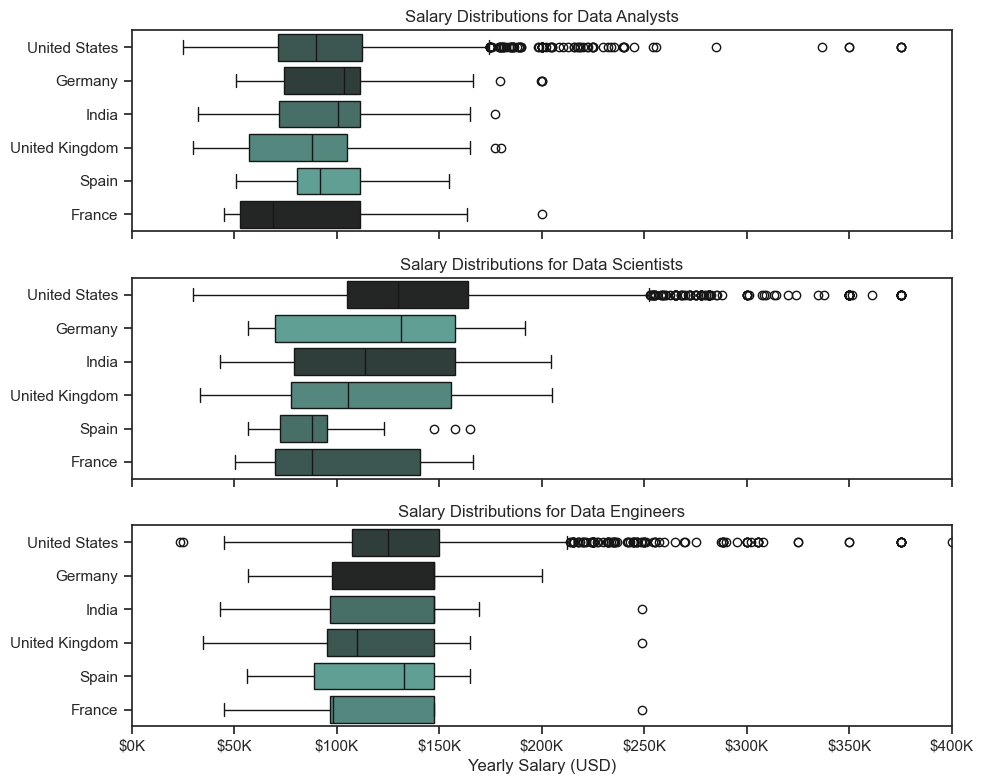

In [13]:
# Prepare Data: Filters top 6 countries
top_countries = df['job_country'].value_counts().index[:6].tolist()
df_filtered = df[df['job_country'].isin(top_countries)]
country_order = df_filtered.groupby('job_country')['salary_year_avg'].median().sort_values(ascending=False).index

# Prepare Data: Defines job titles to iterate through and prepares subplots
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']
fig, axes = plt.subplots(len(job_titles), 1, figsize=(10, 8), sharex=True)

# Create For Loop: Loops through each job title and creates a boxplot
for i, job_title in enumerate(job_titles):

    # Prepare Data: Filters data according to selected job title
    df_job = df_filtered[df_filtered['job_title_short'] == job_title]
    
    # Plot and Visualize
    sns.boxplot(data=df_job, x='salary_year_avg', y='job_country', order=country_order, ax=axes[i], palette='dark:#5A9', hue='job_country', legend=False)

    axes[i].set_title(f'Salary Distributions for {job_title}s')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].set_xlim(0, 400000)

# Customize Plot: Only on last plot
axes[-1].set_xlabel('Yearly Salary (USD)')
axes[-1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# Plot: Finishing
plt.tight_layout()
plt.show()


The United States consistently offers the highest median salaries across all three data roles, with a wide salary range and numerous outliers exceeding $300K, particularly for Data Scientists and Data Engineers. Germany and India follow closely with competitive median salaries, while the United Kingdom, Spain, and France show relatively lower salary distributions.

Data Engineers exhibit the most stable salary distributions across all six countries, with IQRs consistently between $100K-$150K, indicating relatively predictable earnings, regardless of location. Data Scientists display the broadest salary range, spanning from $75K to over $150K, suggesting a greater variation in compensation depending on experience, industry, and specialization. Data Analysts have the narrowest salary range, typically between $60K and $120K, with fewer extreme outliers compared to Data Scientists and Engineers.

Overall, Data Engineers maintain steady compensation across different regions, making this role less affected by geographic fluctuations in pay. Data Scientists have the potential for high earnings, but compensation varies significantly depending on the country, with the U.S. and Germany leading in median salaries. Data Analysts see more moderate salaries across all six countries, with less variation in their pay range.